# Pregunta 1 — Predicción de bajo desempeño en inglés (A−) en Córdoba

**Pregunta de negocio:** ¿Es posible predecir, antes de presentar el Saber 11, si un estudiante de Córdoba quedará en el nivel más bajo de inglés (A−) a partir de su contexto familiar y de su colegio?

**Tipo de problema:** Clasificación binaria.

**Cliente:** Secretaría de Educación de Córdoba.

**Uso del modelo:** focalizar refuerzo de inglés en sedes y municipios con mayor riesgo, antes de la prueba.

**Autor / Rol:** [Samuel Arbeláez] — Análisis de Negocio + Ciencia de Datos.


In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn tensorflow mlflow


  Obtaining dependency information for six>=1.12.0 from https://files.pythonhosted.org/packages/b7/ce/149a00dd41f10bc29e5921b496af8b574d8413afcd5e30dfa0ed46c2cc5e/six-1.17.0-py2.py3-none-any.whl.metadata
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
  Obtaining dependency information for starlette<1 from https://files.pythonhosted.org/packages/81/0d/13d1d239a25cbfb19e740db83143e95c772a1fe10202dda4b76792b114dd/starlette-0.52.1-py3-none-any.whl.metadata
  Obtaining dependency information for anyio<4.0.0,>=3.7.1 from https://files.pythonhosted.org/packages/19/24/44299477fe7dcc9cb58d0a57d5a7588d6af2ff403fdd2d47a246c91a3246/anyio-3.7.1-py3-none-any.whl.metadata
  Using cached anyio-3.7.1-py3-none-any.whl.metadata (4.7 kB)
  Obtaining dependency information for starlette<1 from https://files.pythonhosted.org/packages/58/f8/e2cca22387965584a409795913b774235752be4176d276714e15e1a58884/starlette-0.27.0-py3-none-any.whl.metadata
  Using cached starlette-0.27.0-py3-none-any.whl

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.57.0 requires anyio>=4.0.0, but you have anyio 3.7.1 which is incompatible.
streamlit 1.57.0 requires starlette>=0.40.0, but you have starlette 0.27.0 which is incompatible.

[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Configuración del entorno y MLflow

Cargamos las librerías necesarias y configuramos MLflow para registrar todos los experimentos en la carpeta local `mlruns/`. Esto cumple con el requisito del proyecto de documentar el modelamiento con MLflow.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import mlflow
import mlflow.keras
import mlflow.sklearn

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Saber11_Cordoba_Ingles_A-")

print("Librerías cargadas correctamente.")
print("TensorFlow versión:", tf.__version__)


c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydantic\_internal\_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/07 16:35:36 INFO mlflow.tracking.fluent: Experiment with name 'Saber11_Cordoba_Ingles_A-' does not exist. Creating a new experiment.


Librerías cargadas correctamente.
TensorFlow versión: 2.20.0


## 2. Carga de datos

Usamos los datos limpios de la Tarea 2 (`Resultados_ICFES_Cordoba_clean.csv`). El dataset contiene los resultados de la prueba Saber 11 para estudiantes del departamento de Córdoba.


In [3]:
df = pd.read_csv("../Resultados_ICFES_Cordoba_clean.csv")
print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
df.head()


Filas: 194,259  |  Columnas: 51


,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,...,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20224,TI,SB11202240331749,URBANO,N,A,ACADÉMICO,1.230900e+11,123090000301,23,...,NO,NO,SI,A-,43.0,50.0,42.0,46.0,52.0,236.0
1,20224,TI,SB11202240555914,RURAL,N,A,ACADÉMICO,2.231620e+11,223162001662,23,...,NO,NO,SI,A2,59.0,54.0,51.0,57.0,49.0,266.0
2,20224,TI,SB11202240559153,RURAL,NaN,A,NO APLICA,2.236700e+11,223670000507,23,...,NO,NO,NO,A-,34.0,37.0,28.0,36.0,41.0,177.0
3,20224,TI,SB11202240526915,RURAL,NaN,A,ACADÉMICO,2.236600e+11,223660001084,23,...,NaN,NaN,NaN,A-,41.0,63.0,63.0,58.0,60.0,297.0
4,20224,TI,SB11202240311533,URBANO,N,A,ACADÉMICO,3.230010e+11,323001004178,23,...,SI,SI,SI,A1,56.0,72.0,52.0,59.0,65.0,308.0


## 3. Definición de la variable objetivo

La columna `desemp_ingles` clasifica a cada estudiante en uno de cinco niveles según el Marco Común Europeo: **A−, A1, A2, B1, B+**. El nivel **A−** es el más bajo y representa estudiantes que no alcanzan ni el básico inicial (A1).

Construimos una variable binaria:

- `target = 1` si el estudiante quedó en **A−** (caso de riesgo).
- `target = 0` si quedó en **A1, A2, B1 o B+**.

Esto convierte el problema en una clasificación binaria, alineada con la pregunta de negocio (riesgo vs. no riesgo).


In [4]:
df = df.dropna(subset=["desemp_ingles"]).copy()
df["target"] = (df["desemp_ingles"] == "A-").astype(int)

print("Distribución de la variable objetivo:")
print(df["target"].value_counts())
print()
print("Proporción:")
print(df["target"].value_counts(normalize=True).round(3))


Distribución de la variable objetivo:
target
1    118336
0     75734
Name: count, dtype: int64

Proporción:
target
1    0.61
0    0.39
Name: proportion, dtype: float64


## 4. Selección y justificación de variables

Solo se incluyen variables disponibles **antes** de presentar la prueba (no se usan los puntajes `punt_*`, que serían *data leakage*). También se descartan identificadores y campos redundantes.

### Variables del colegio (institucional)
- `cole_area_ubicacion` — Urbano/Rural. Brecha educativa documentada en Colombia.
- `cole_naturaleza` — Oficial / No oficial. Indicador de recursos.
- `cole_jornada` — Mañana, tarde, noche, completa, única. Tiempo lectivo asociado.
- `cole_calendario` — A / B. Tipo de calendario académico.
- `cole_caracter` — Académico, técnico, etc.
- `cole_bilingue` — Si el colegio es bilingüe (esperamos fuerte impacto en inglés).
- `cole_genero` — Mixto, masculino, femenino.

### Variables familiares (socioeconómicas)
- `fami_estratovivienda` — Estrato 1 a 6 (ordinal).
- `fami_educacionmadre`, `fami_educacionpadre` — Capital cultural del hogar.
- `fami_tieneinternet`, `fami_tienecomputador`, `fami_tieneautomovil`, `fami_tienelavadora` — Recursos materiales en el hogar.
- `fami_cuartoshogar`, `fami_personashogar` — Hacinamiento.

### Variables del estudiante
- `estu_genero` — Femenino / Masculino.
- `edad` — Calculada desde `estu_fechanacimiento`.

Se excluyen: `cole_cod_*`, `estu_consecutivo`, identificadores DANE, fechas crudas y todos los `punt_*`.


In [5]:
df["estu_fechanacimiento"] = pd.to_datetime(df["estu_fechanacimiento"], errors="coerce")
df["edad"] = (pd.to_datetime("2022-12-31") - df["estu_fechanacimiento"]).dt.days // 365

cat_features = ["cole_area_ubicacion", "cole_naturaleza", "cole_jornada",
                "cole_calendario", "cole_caracter", "cole_bilingue", "cole_genero",
                "estu_genero", "fami_tieneinternet", "fami_tienecomputador",
                "fami_tieneautomovil", "fami_tienelavadora"]

ord_features = ["fami_estratovivienda", "fami_educacionmadre", "fami_educacionpadre",
                "fami_cuartoshogar", "fami_personashogar"]

num_features = ["edad"]

features = cat_features + ord_features + num_features

X = df[features].copy()
y = df["target"].copy()

print(f"Total features: {len(features)}")
print(f"Categóricas: {len(cat_features)} | Ordinales: {len(ord_features)} | Numéricas: {len(num_features)}")
print(f"Filas válidas: X={X.shape[0]:,}, y={y.shape[0]:,}")

# Revisión rápida de nulos
print("\nNulos por columna:")
print(X.isnull().sum().sort_values(ascending=False).head(10))


Total features: 18
Categóricas: 12 | Ordinales: 5 | Numéricas: 1
Filas válidas: X=194,070, y=194,070

Nulos por columna:
cole_bilingue           34503
fami_estratovivienda     4277
fami_educacionmadre      3840
fami_educacionpadre      3827
fami_tieneinternet       3642
fami_tienecomputador     2524
fami_tieneautomovil      2505
fami_personashogar       2460
fami_cuartoshogar        2454
fami_tienelavadora       2395
dtype: int64


## 5. Tratamiento de valores nulos

- **`cole_bilingue`** (18% nulos): cuando no aparece declarado, lo asumimos como "N" (no bilingüe). Es la interpretación más sensata: si fuera bilingüe, el colegio lo habría reportado.
- **Variables familiares** (1–2% nulos): los rellenamos con la categoría `"NO INFORMA"`, ya que el hecho de no responder puede ser informativo en sí mismo.
- **`edad`**: imputamos con la mediana en caso de fechas mal capturadas.


In [7]:
X["cole_bilingue"] = X["cole_bilingue"].fillna("N")
X["edad"] = X["edad"].fillna(X["edad"].median())

for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].fillna("NO INFORMA")

print("Nulos restantes:", X.isnull().sum().sum())
print("\nDetalle por columna (solo las que aún tienen nulos):")
print(X.isnull().sum()[X.isnull().sum() > 0])



Nulos restantes: 0

Detalle por columna (solo las que aún tienen nulos):
Series([], dtype: int64)


## 6. División train / validación / test

Dividimos el dataset en 70% entrenamiento, 15% validación y 15% test, con **estratificación** para preservar la proporción de la clase A− (61%) en cada split.

- **Train** se usa para ajustar los modelos.
- **Validación** se usa para comparar configuraciones y elegir el mejor modelo.
- **Test** se reserva y solo se evalúa al final con el modelo ganador, para tener una estimación honesta del desempeño en producción.


In [8]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176, stratify=y_trainval, random_state=42)

print(f"Train: {len(X_train):,}  ({y_train.mean():.1%} A-)")
print(f"Val:   {len(X_val):,}  ({y_val.mean():.1%} A-)")
print(f"Test:  {len(X_test):,}  ({y_test.mean():.1%} A-)")


Train: 135,926  (61.0% A-)
Val:   29,033  (61.0% A-)
Test:  29,111  (61.0% A-)


## 7. Preprocesamiento

Construimos un `ColumnTransformer` que transforma las features para que sean consumibles por la red neuronal:

- **OneHotEncoder** sobre las variables categóricas y ordinales. Para simplificar y dado que la red neuronal puede aprender las relaciones, tratamos las ordinales como nominales en esta primera versión.
- **StandardScaler** sobre la única numérica (`edad`).

El preprocesador se ajusta **solo con `X_train`** para evitar *data leakage*, y luego se aplica a validación y test.


In [9]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
     cat_features + ord_features),
    ("num", StandardScaler(), num_features),
])

X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)

print(f"Shape después de preprocesamiento:")
print(f"  X_train: {X_train_p.shape}")
print(f"  X_val:   {X_val_p.shape}")
print(f"  X_test:  {X_test_p.shape}")


Shape después de preprocesamiento:
  X_train: (135926, 102)
  X_val:   (29033, 102)
  X_test:  (29111, 102)


## 8. Modelo baseline: regresión logística

Antes de entrenar la red neuronal, ajustamos una **regresión logística** como referencia. Esto es importante por dos razones:

1. **Justificar la complejidad de la red neuronal.** Si la red no supera al baseline, no se justifica usarla.
2. **Tener un punto de comparación claro** en MLflow para todos los experimentos posteriores.

Usamos `class_weight="balanced"` aunque el desbalance es leve (61/39), para reflejar el costo asimétrico: detectar correctamente a un estudiante en riesgo (A−) es más valioso que un falso positivo.

**Métricas evaluadas:**
- **F1-score** sobre la clase positiva (riesgo A−).
- **ROC-AUC**: capacidad de discriminar entre las dos clases.
- **PR-AUC** (Average Precision): más informativa cuando importa la clase positiva.


In [10]:
with mlflow.start_run(run_name="baseline_logreg"):
    mlflow.log_param("modelo", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("max_iter", 1000)

    base = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
    base.fit(X_train_p, y_train)

    y_val_pred  = base.predict(X_val_p)
    y_val_proba = base.predict_proba(X_val_p)[:, 1]

    f1  = f1_score(y_val, y_val_pred)
    auc = roc_auc_score(y_val, y_val_proba)
    pr  = average_precision_score(y_val, y_val_proba)

    mlflow.log_metric("val_f1",      f1)
    mlflow.log_metric("val_roc_auc", auc)
    mlflow.log_metric("val_pr_auc",  pr)

    mlflow.sklearn.log_model(base, "modelo")

    print(f"Baseline LogReg | F1={f1:.4f}  ROC-AUC={auc:.4f}  PR-AUC={pr:.4f}")
    print("\nReporte clasificación (validación):")
    print(classification_report(y_val, y_val_pred, target_names=["No A-", "A-"]))


2026/05/07 16:42:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 16:42:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Baseline LogReg | F1=0.7213  ROC-AUC=0.7037  PR-AUC=0.7597

Reporte clasificación (validación):
              precision    recall  f1-score   support

       No A-       0.57      0.58      0.57     11330
          A-       0.73      0.71      0.72     17703

    accuracy                           0.66     29033
   macro avg       0.65      0.65      0.65     29033
weighted avg       0.66      0.66      0.66     29033



## 9. Red neuronal — arquitectura base

Construimos un **MLP** (Multi-Layer Perceptron) como primer experimento de red neuronal:

- **Input**: 102 features (resultado del preprocesamiento).
- **2 capas ocultas** (64 y 32 neuronas) con activación **ReLU**.
- **Dropout 0.3** entre capas para regularizar y evitar sobreajuste.
- **Capa de salida**: 1 neurona con activación **sigmoide** (probabilidad de A−).
- **Pérdida**: `binary_crossentropy`.
- **Optimizador**: Adam con learning rate 1e-3.
- **EarlyStopping**: detiene el entrenamiento si la pérdida en validación no mejora en 5 épocas.

Para manejar el desbalance leve, calculamos `class_weight` balanceado.


In [12]:
def build_mlp(input_dim, hidden=(64, 32), dropout=0.3, lr=1e-3):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for h in hidden:
        model.add(layers.Dense(h, activation="relu"))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), "accuracy"]
    )
    return model

cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
class_weight = {0: cw[0], 1: cw[1]}
print(f"Class weights: {class_weight}")

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True)

with mlflow.start_run(run_name="nn_base_64_32"):
    mlflow.log_params({
        "modelo": "MLP",
        "hidden": "64-32",
        "dropout": 0.3,
        "lr": 1e-3,
        "batch_size": 256,
        "epochs_max": 50,
        "class_weight": "balanced",
    })

    model = build_mlp(X_train_p.shape[1], hidden=(64, 32), dropout=0.3, lr=1e-3)
    history = model.fit(
        X_train_p, y_train,
        validation_data=(X_val_p, y_val),
        epochs=50, batch_size=256,
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=2
    )

    y_val_proba = model.predict(X_val_p, verbose=0).ravel()
    y_val_pred  = (y_val_proba >= 0.5).astype(int)

    f1  = f1_score(y_val, y_val_pred)
    auc = roc_auc_score(y_val, y_val_proba)
    pr  = average_precision_score(y_val, y_val_proba)

    mlflow.log_metric("val_f1",      f1)
    mlflow.log_metric("val_roc_auc", auc)
    mlflow.log_metric("val_pr_auc",  pr)
    mlflow.log_metric("epochs_run",  len(history.history["loss"]))

    print(f"\nNN base | F1={f1:.4f}  ROC-AUC={auc:.4f}  PR-AUC={pr:.4f}")
    print(classification_report(y_val, y_val_pred, target_names=["No A-", "A-"]))



Class weights: {0: 1.281257069602594, 1: 0.8199971043169808}
Epoch 1/50
531/531 - 2s - 4ms/step - accuracy: 0.6560 - auc: 0.6788 - loss: 0.6371 - val_accuracy: 0.6753 - val_auc: 0.7046 - val_loss: 0.6176
Epoch 2/50
531/531 - 1s - 2ms/step - accuracy: 0.6683 - auc: 0.6981 - loss: 0.6252 - val_accuracy: 0.6741 - val_auc: 0.7070 - val_loss: 0.6178
Epoch 3/50
531/531 - 1s - 2ms/step - accuracy: 0.6703 - auc: 0.7023 - loss: 0.6220 - val_accuracy: 0.6746 - val_auc: 0.7081 - val_loss: 0.6163
Epoch 4/50
531/531 - 1s - 2ms/step - accuracy: 0.6721 - auc: 0.7048 - loss: 0.6201 - val_accuracy: 0.6745 - val_auc: 0.7081 - val_loss: 0.6153
Epoch 5/50
531/531 - 1s - 2ms/step - accuracy: 0.6719 - auc: 0.7064 - loss: 0.6189 - val_accuracy: 0.6688 - val_auc: 0.7091 - val_loss: 0.6198
Epoch 6/50
531/531 - 1s - 2ms/step - accuracy: 0.6728 - auc: 0.7077 - loss: 0.6183 - val_accuracy: 0.6790 - val_auc: 0.7076 - val_loss: 0.6125
Epoch 7/50
531/531 - 1s - 2ms/step - accuracy: 0.6735 - auc: 0.7090 - loss: 0.617

In [13]:
print(f"NN base | F1={f1:.4f}  ROC-AUC={auc:.4f}  PR-AUC={pr:.4f}")
print(classification_report(y_val, y_val_pred, target_names=["No A-", "A-"]))


NN base | F1=0.7488  ROC-AUC=0.7083  PR-AUC=0.7668
              precision    recall  f1-score   support

       No A-       0.60      0.53      0.56     11330
          A-       0.72      0.78      0.75     17703

    accuracy                           0.68     29033
   macro avg       0.66      0.65      0.66     29033
weighted avg       0.68      0.68      0.68     29033



## 10. Experimentos: variando la arquitectura

Probamos múltiples configuraciones de la red neuronal para encontrar la mejor combinación. Cada experimento se registra en MLflow:

| Experimento | Capas ocultas | Dropout | Learning rate |
|---|---|---|---|
| 1 | 32 - 16 | 0.2 | 1e-3 |
| 2 | 128 - 64 | 0.4 | 1e-3 |
| 3 | 128 - 64 - 32 | 0.3 | 1e-3 |
| 4 | 64 - 32 | 0.3 | 1e-4 |
| 5 | 256 - 128 - 64 | 0.5 | 1e-3 |

Comparamos por **F1**, **ROC-AUC** y **PR-AUC** sobre el conjunto de validación.


In [14]:
experimentos = [
    {"name": "nn_small_32_16",       "hidden": (32, 16),       "dropout": 0.2, "lr": 1e-3},
    {"name": "nn_med_128_64",        "hidden": (128, 64),      "dropout": 0.4, "lr": 1e-3},
    {"name": "nn_deep_128_64_32",    "hidden": (128, 64, 32),  "dropout": 0.3, "lr": 1e-3},
    {"name": "nn_lowlr_64_32",       "hidden": (64, 32),       "dropout": 0.3, "lr": 1e-4},
    {"name": "nn_big_256_128_64",    "hidden": (256, 128, 64), "dropout": 0.5, "lr": 1e-3},
]

resultados = []

for exp in experimentos:
    with mlflow.start_run(run_name=exp["name"]):
        mlflow.log_params({
            "modelo": "MLP",
            "hidden": "-".join(map(str, exp["hidden"])),
            "dropout": exp["dropout"],
            "lr": exp["lr"],
            "batch_size": 256,
            "class_weight": "balanced",
        })

        model = build_mlp(X_train_p.shape[1],
                          hidden=exp["hidden"],
                          dropout=exp["dropout"],
                          lr=exp["lr"])

        model.fit(X_train_p, y_train,
                  validation_data=(X_val_p, y_val),
                  epochs=50, batch_size=256,
                  class_weight=class_weight,
                  callbacks=[keras.callbacks.EarlyStopping(
                      monitor="val_loss", patience=5, restore_best_weights=True)],
                  verbose=0)

        y_proba = model.predict(X_val_p, verbose=0).ravel()
        y_pred  = (y_proba >= 0.5).astype(int)

        f1  = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_proba)
        pr  = average_precision_score(y_val, y_proba)

        mlflow.log_metric("val_f1",      f1)
        mlflow.log_metric("val_roc_auc", auc)
        mlflow.log_metric("val_pr_auc",  pr)

        resultados.append({"experimento": exp["name"], "F1": f1, "ROC-AUC": auc, "PR-AUC": pr})
        print(f"{exp['name']:<30} F1={f1:.4f}  AUC={auc:.4f}  PR-AUC={pr:.4f}")

print("\nResumen:")
pd.DataFrame(resultados).sort_values("F1", ascending=False)


nn_small_32_16                 F1=0.7450  AUC=0.7088  PR-AUC=0.7670
nn_med_128_64                  F1=0.7450  AUC=0.7086  PR-AUC=0.7674
nn_deep_128_64_32              F1=0.7540  AUC=0.7074  PR-AUC=0.7661
nn_lowlr_64_32                 F1=0.7363  AUC=0.7088  PR-AUC=0.7673
nn_big_256_128_64              F1=0.7364  AUC=0.7081  PR-AUC=0.7661

Resumen:


,experimento,F1,ROC-AUC,PR-AUC
2,nn_deep_128_64_32,0.754005,0.707362,0.766107
0,nn_small_32_16,0.744999,0.708774,0.767013
1,nn_med_128_64,0.744957,0.708585,0.767361
4,nn_big_256_128_64,0.736368,0.708059,0.766139
3,nn_lowlr_64_32,0.736324,0.708761,0.767294


## 11. Modelo final: evaluación en test

Tras los experimentos, seleccionamos la arquitectura **128-64-32** con dropout 0.3, que obtuvo el mejor F1 en validación.

Re-entrenamos esta arquitectura usando **train + validación** combinados (para aprovechar más datos) y la evaluamos por primera vez sobre el conjunto de **test**, que se mantuvo aislado durante todo el desarrollo.

Esta es la métrica honesta de desempeño esperado en producción.


In [15]:
X_full_p = np.vstack([X_train_p, X_val_p])
y_full   = pd.concat([y_train, y_val])

cw_full = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_full)
class_weight_full = {0: cw_full[0], 1: cw_full[1]}

with mlflow.start_run(run_name="nn_FINAL_128_64_32"):
    mlflow.log_params({
        "modelo": "MLP_FINAL",
        "hidden": "128-64-32",
        "dropout": 0.3,
        "lr": 1e-3,
        "batch_size": 256,
        "class_weight": "balanced",
        "datos_entrenamiento": "train+val",
    })

    final_model = build_mlp(X_full_p.shape[1], hidden=(128, 64, 32), dropout=0.3, lr=1e-3)
    final_model.fit(X_full_p, y_full,
                    epochs=30, batch_size=256,
                    class_weight=class_weight_full,
                    verbose=0)

    y_test_proba = final_model.predict(X_test_p, verbose=0).ravel()
    y_test_pred  = (y_test_proba >= 0.5).astype(int)

    f1_t  = f1_score(y_test, y_test_pred)
    auc_t = roc_auc_score(y_test, y_test_proba)
    pr_t  = average_precision_score(y_test, y_test_proba)

    mlflow.log_metric("test_f1",      f1_t)
    mlflow.log_metric("test_roc_auc", auc_t)
    mlflow.log_metric("test_pr_auc",  pr_t)

    print("=== EVALUACIÓN FINAL EN TEST ===")
    print(f"F1={f1_t:.4f}  ROC-AUC={auc_t:.4f}  PR-AUC={pr_t:.4f}\n")
    print(classification_report(y_test, y_test_pred, target_names=["No A-", "A-"]))
    print("\nMatriz de confusión:")
    print(confusion_matrix(y_test, y_test_pred))


=== EVALUACIÓN FINAL EN TEST ===
F1=0.7176  ROC-AUC=0.7095  PR-AUC=0.7652

              precision    recall  f1-score   support

       No A-       0.56      0.60      0.58     11360
          A-       0.73      0.70      0.72     17751

    accuracy                           0.66     29111
   macro avg       0.65      0.65      0.65     29111
weighted avg       0.67      0.66      0.66     29111


Matriz de confusión:
[[ 6795  4565]
 [ 5263 12488]]


## 13. Optimización del umbral de decisión

Por defecto clasificamos como A− cuando la probabilidad predicha es ≥ 0.5. Pero ese umbral no necesariamente maximiza el F1. Buscamos el umbral óptimo barriendo valores entre 0.3 y 0.7 sobre el conjunto de validación, y luego evaluamos con ese umbral en test.


Mejor threshold: 0.29
  F1=0.7905  Precision=0.6764  Recall=0.9507

Threshold = 0.50 (referencia):
  F1=0.7332  Precision=0.7445  Recall=0.7221


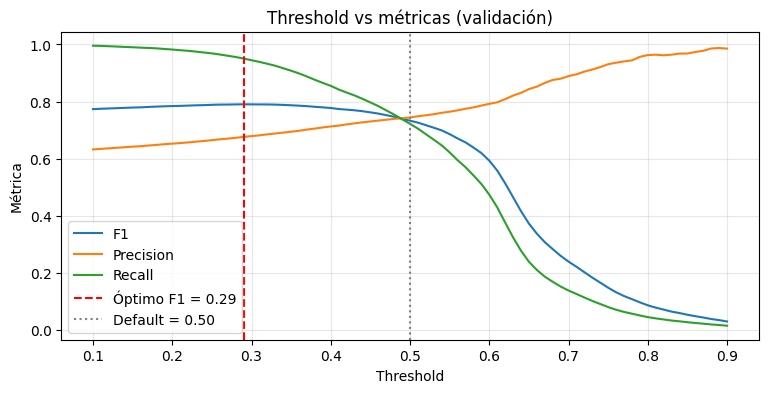


=== TEST con threshold óptimo ===
              precision    recall  f1-score   support

       No A-       0.76      0.27      0.40     11360
          A-       0.67      0.94      0.78     17751

    accuracy                           0.68     29111
   macro avg       0.71      0.61      0.59     29111
weighted avg       0.70      0.68      0.63     29111



In [17]:
y_val_proba_final = final_model.predict(X_val_p, verbose=0).ravel()

from sklearn.metrics import precision_score, recall_score

thresholds = np.arange(0.10, 0.91, 0.01)
f1s, precisions, recalls = [], [], []

for t in thresholds:
    pred = (y_val_proba_final >= t).astype(int)
    f1s.append(f1_score(y_val, pred))
    precisions.append(precision_score(y_val, pred, zero_division=0))
    recalls.append(recall_score(y_val, pred))

best_idx = int(np.argmax(f1s))
best_t = thresholds[best_idx]

# Para comparar con 0.5 buscamos el más cercano
default_idx = int(np.argmin(np.abs(thresholds - 0.5)))

print(f"Mejor threshold: {best_t:.2f}")
print(f"  F1={f1s[best_idx]:.4f}  Precision={precisions[best_idx]:.4f}  Recall={recalls[best_idx]:.4f}")
print(f"\nThreshold = 0.50 (referencia):")
print(f"  F1={f1s[default_idx]:.4f}  Precision={precisions[default_idx]:.4f}  Recall={recalls[default_idx]:.4f}")

plt.figure(figsize=(9,4))
plt.plot(thresholds, f1s, label="F1")
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.axvline(best_t, color="red", linestyle="--", label=f"Óptimo F1 = {best_t:.2f}")
plt.axvline(0.5, color="gray", linestyle=":", label="Default = 0.50")
plt.xlabel("Threshold"); plt.ylabel("Métrica")
plt.title("Threshold vs métricas (validación)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

# Evaluar con el mejor threshold en test
y_test_pred_opt = (y_test_proba >= best_t).astype(int)

with mlflow.start_run(run_name="nn_FINAL_threshold_opt"):
    mlflow.log_param("threshold", float(best_t))
    mlflow.log_metric("test_f1",        f1_score(y_test, y_test_pred_opt))
    mlflow.log_metric("test_precision", precision_score(y_test, y_test_pred_opt))
    mlflow.log_metric("test_recall",    recall_score(y_test, y_test_pred_opt))

print("\n=== TEST con threshold óptimo ===")
print(classification_report(y_test, y_test_pred_opt, target_names=["No A-", "A-"]))


## 14. Mejora del modelo: features locales (municipio y colegio)

Hipótesis: el desempeño en inglés varía mucho entre municipios y entre colegios específicos (algunos colegios tienen mejores profesores, infraestructura, programas bilingües informales, etc.). Agregar estas variables debería capturar esa heterogeneidad y subir la capacidad predictiva del modelo (AUC, no solo F1).

- **`cole_mcpio_ubicacion`**: municipio donde queda el colegio. Cardinalidad media (~30 municipios en Córdoba).
- **`cole_nombre_establecimiento`**: nombre específico del colegio. Alta cardinalidad. Para evitar explosión de features, agrupamos los colegios con menos de 50 estudiantes en una categoría única `"otro"`.


In [18]:
print("Cardinalidad de las nuevas features:")
print(f"  Municipios:    {df['cole_mcpio_ubicacion'].nunique()}")
print(f"  Colegios:      {df['cole_nombre_establecimiento'].nunique()}")

print("\nDistribución de tamaños de colegio (cuántos estudiantes por colegio):")
counts = df["cole_nombre_establecimiento"].value_counts()
print(counts.describe())


Cardinalidad de las nuevas features:
  Municipios:    33
  Colegios:      483

Distribución de tamaños de colegio (cuántos estudiantes por colegio):
count     483.000000
mean      401.801242
std       447.254824
min         1.000000
25%        89.000000
50%       241.000000
75%       544.000000
max      3218.000000
Name: count, dtype: float64


## 15. Re-entrenamiento con features locales

Estrategia:
- **Municipio (`cole_mcpio_ubicacion`)**: one-hot encoding (33 columnas).
- **Colegio (`cole_nombre_establecimiento`)**: *target encoding con smoothing* — cada colegio se representa por su tasa esperada de A−, calculada **solo en el conjunto de entrenamiento** (sin leakage). Para colegios pequeños, suavizamos hacia el promedio global usando la fórmula:

$$
\text{enc}(c) = \frac{n_c \cdot p_c + m \cdot p_{\text{global}}}{n_c + m}
$$

donde $n_c$ es el número de estudiantes del colegio en train, $p_c$ la proporción de A− en ese colegio, $p_{\text{global}}$ el promedio en train, y $m=20$ el factor de suavizamiento.

Re-entrenamos la arquitectura ganadora (128-64-32) con estas features adicionales.


In [21]:
# 1) Reconstruir X con las nuevas columnas
df_full = df.copy()
df_full["cole_mcpio_ubicacion"]      = df_full["cole_mcpio_ubicacion"].fillna("NO INFORMA")
df_full["cole_nombre_establecimiento"] = df_full["cole_nombre_establecimiento"].fillna("NO INFORMA")

cat_features_v2 = cat_features + ["cole_mcpio_ubicacion"]
features_v2 = cat_features_v2 + ord_features + num_features + ["cole_nombre_establecimiento"]

X2 = df_full[features_v2].copy()
# imputar nulos en las que ya tratamos
for col in X2.select_dtypes(include="object").columns:
    X2[col] = X2[col].fillna("NO INFORMA")
X2["edad"] = X2["edad"].fillna(X2["edad"].median())

y2 = df_full["target"].copy()

# 2) Splits con la misma semilla para que sean comparables
X2_trainval, X2_test, y2_trainval, y2_test = train_test_split(
    X2, y2, test_size=0.15, stratify=y2, random_state=42)
X2_train, X2_val, y2_train, y2_val = train_test_split(
    X2_trainval, y2_trainval, test_size=0.176, stratify=y2_trainval, random_state=42)

# 3) Target encoding del colegio (solo con train)
m = 20
p_global = y2_train.mean()
agg = pd.DataFrame({"col": X2_train["cole_nombre_establecimiento"], "y": y2_train.values})
agg = agg.groupby("col")["y"].agg(["mean", "count"])
agg["enc"] = (agg["count"] * agg["mean"] + m * p_global) / (agg["count"] + m)
school_enc = agg["enc"].to_dict()

def encode_school(s):
    return s.map(school_enc).fillna(p_global)

X2_train["colegio_enc"] = encode_school(X2_train["cole_nombre_establecimiento"])
X2_val["colegio_enc"]   = encode_school(X2_val["cole_nombre_establecimiento"])
X2_test["colegio_enc"]  = encode_school(X2_test["cole_nombre_establecimiento"])

for s in [X2_train, X2_val, X2_test]:
    s.drop(columns=["cole_nombre_establecimiento"], inplace=True)

# 4) Preprocesador v2
preprocessor_v2 = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
     cat_features_v2 + ord_features),
    ("num", StandardScaler(), num_features + ["colegio_enc"]),
])

X2_train_p = preprocessor_v2.fit_transform(X2_train)
X2_val_p   = preprocessor_v2.transform(X2_val)
X2_test_p  = preprocessor_v2.transform(X2_test)

print(f"Nuevo shape: train {X2_train_p.shape}, val {X2_val_p.shape}, test {X2_test_p.shape}")

# 5) Entrenar el modelo ganador con estas features
cw2 = compute_class_weight("balanced", classes=np.array([0, 1]), y=y2_train)
class_weight_v2 = {0: cw2[0], 1: cw2[1]}

with mlflow.start_run(run_name="nn_v2_con_municipio_colegio"):
    mlflow.log_params({
        "modelo": "MLP_v2",
        "hidden": "128-64-32",
        "dropout": 0.3,
        "lr": 1e-3,
        "features_extra": "municipio_onehot + colegio_targetenc",
    })


Nuevo shape: train (135926, 137), val (29033, 137), test (29111, 137)


In [22]:
cw2 = compute_class_weight("balanced", classes=np.array([0, 1]), y=y2_train)
class_weight_v2 = {0: cw2[0], 1: cw2[1]}

model_v2 = build_mlp(X2_train_p.shape[1], hidden=(128, 64, 32), dropout=0.3, lr=1e-3)

print("Entrenando v2... (puede tardar 1-3 min)")
history_v2 = model_v2.fit(
    X2_train_p, y2_train,
    validation_data=(X2_val_p, y2_val),
    epochs=50, batch_size=256,
    class_weight=class_weight_v2,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=2
)

y_val_proba_v2 = model_v2.predict(X2_val_p, verbose=0).ravel()
y_val_pred_v2  = (y_val_proba_v2 >= 0.5).astype(int)

f1_v2  = f1_score(y2_val, y_val_pred_v2)
auc_v2 = roc_auc_score(y2_val, y_val_proba_v2)
pr_v2  = average_precision_score(y2_val, y_val_proba_v2)

print(f"\n=== NN v2 (con municipio + colegio) ===")
print(f"VAL: F1={f1_v2:.4f}  ROC-AUC={auc_v2:.4f}  PR-AUC={pr_v2:.4f}")
print(f"\nReferencia v1 (sin esas features):")
print(f"VAL: F1=0.7540  ROC-AUC=0.7074  PR-AUC=0.7661")


Entrenando v2... (puede tardar 1-3 min)
Epoch 1/50
531/531 - 4s - 7ms/step - accuracy: 0.6746 - auc: 0.7127 - loss: 0.6143 - val_accuracy: 0.6818 - val_auc: 0.7311 - val_loss: 0.6042
Epoch 2/50
531/531 - 2s - 4ms/step - accuracy: 0.6872 - auc: 0.7288 - loss: 0.6017 - val_accuracy: 0.6923 - val_auc: 0.7342 - val_loss: 0.5929
Epoch 3/50
531/531 - 2s - 4ms/step - accuracy: 0.6873 - auc: 0.7323 - loss: 0.5993 - val_accuracy: 0.6890 - val_auc: 0.7343 - val_loss: 0.5986
Epoch 4/50
531/531 - 2s - 4ms/step - accuracy: 0.6863 - auc: 0.7348 - loss: 0.5971 - val_accuracy: 0.6940 - val_auc: 0.7355 - val_loss: 0.5901
Epoch 5/50
531/531 - 2s - 4ms/step - accuracy: 0.6876 - auc: 0.7368 - loss: 0.5953 - val_accuracy: 0.6871 - val_auc: 0.7358 - val_loss: 0.5926
Epoch 6/50
531/531 - 2s - 4ms/step - accuracy: 0.6874 - auc: 0.7380 - loss: 0.5945 - val_accuracy: 0.6933 - val_auc: 0.7350 - val_loss: 0.5888
Epoch 7/50
531/531 - 2s - 4ms/step - accuracy: 0.6893 - auc: 0.7391 - loss: 0.5931 - val_accuracy: 0.6

## 16. Evaluación final del modelo v2

Aplicamos a v2 las dos mejoras conjuntas:
1. Optimización del threshold de decisión sobre validación.
2. Evaluación final en el conjunto de test (intacto).
3. Re-serialización del modelo y preprocesador para uso en el tablero.


In [23]:
# 1) Tunear threshold con validación
y_val_proba_v2 = model_v2.predict(X2_val_p, verbose=0).ravel()
thresholds = np.arange(0.10, 0.91, 0.01)
f1s = [f1_score(y2_val, (y_val_proba_v2 >= t).astype(int)) for t in thresholds]
best_t_v2 = float(thresholds[int(np.argmax(f1s))])
print(f"Mejor threshold v2: {best_t_v2:.2f} (F1 val = {max(f1s):.4f})")

# 2) Evaluar en TEST con ese threshold
y_test_proba_v2 = model_v2.predict(X2_test_p, verbose=0).ravel()
y_test_pred_v2  = (y_test_proba_v2 >= best_t_v2).astype(int)

with mlflow.start_run(run_name="nn_v2_FINAL_threshold_opt"):
    mlflow.log_param("threshold", best_t_v2)
    mlflow.log_metric("test_f1",        f1_score(y2_test, y_test_pred_v2))
    mlflow.log_metric("test_roc_auc",   roc_auc_score(y2_test, y_test_proba_v2))
    mlflow.log_metric("test_pr_auc",    average_precision_score(y2_test, y_test_proba_v2))
    mlflow.log_metric("test_precision", precision_score(y2_test, y_test_pred_v2))
    mlflow.log_metric("test_recall",    recall_score(y2_test, y_test_pred_v2))

print("\n=== EVALUACIÓN FINAL v2 EN TEST ===")
print(f"F1={f1_score(y2_test, y_test_pred_v2):.4f}")
print(f"ROC-AUC={roc_auc_score(y2_test, y_test_proba_v2):.4f}")
print(f"PR-AUC={average_precision_score(y2_test, y_test_proba_v2):.4f}\n")
print(classification_report(y2_test, y_test_pred_v2, target_names=["No A-", "A-"]))
print("Matriz de confusión:")
print(confusion_matrix(y2_test, y_test_pred_v2))

# 3) Re-serializar el modelo final + preprocesador + threshold + school encoding
import joblib
model_v2.save("modelos/modelo_ingles_A-_v2.keras")
joblib.dump(preprocessor_v2, "modelos/preprocessor_ingles_A-_v2.pkl")
joblib.dump({"threshold": best_t_v2,
             "school_encoding": school_enc,
             "p_global": float(p_global)},
            "modelos/metadata_ingles_A-_v2.pkl")

print("\nArchivos guardados:")
import os
for f in sorted(os.listdir("modelos")):
    size_kb = os.path.getsize(f"modelos/{f}") / 1024
    print(f"  modelos/{f}  ({size_kb:.1f} KB)")


Mejor threshold v2: 0.33 (F1 val = 0.7926)

=== EVALUACIÓN FINAL v2 EN TEST ===
F1=0.7940
ROC-AUC=0.7399
PR-AUC=0.7918

              precision    recall  f1-score   support

       No A-       0.79      0.31      0.45     11360
          A-       0.68      0.95      0.79     17751

    accuracy                           0.70     29111
   macro avg       0.74      0.63      0.62     29111
weighted avg       0.73      0.70      0.66     29111

Matriz de confusión:
[[ 3544  7816]
 [  920 16831]]

Archivos guardados:
  modelos/metadata_ingles_A-_v2.pkl  (20.5 KB)
  modelos/modelo_ingles_A-_v2.keras  (364.9 KB)
  modelos/preprocessor_ingles_A-_v2.pkl  (8.4 KB)


## 17. Interpretabilidad: ¿qué variables pesan más?

Calculamos la *permutation importance* sobre validación: medimos cuánto baja la AUC si permutamos aleatoriamente cada feature. Mientras más caiga la AUC, más importante es esa variable para el modelo. Esto le da a la Secretaría pistas sobre dónde están las palancas reales del problema.


RF AUC val: 0.7291


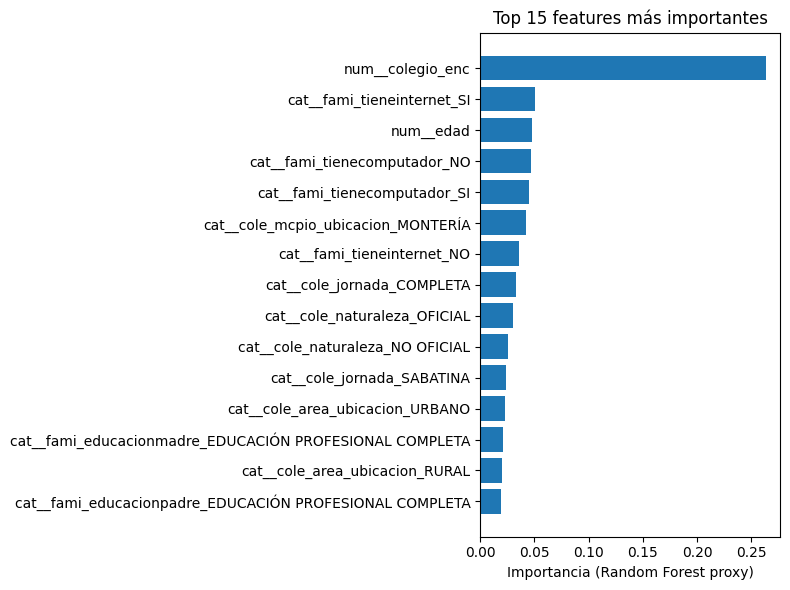


Top 15:
                                                feature  importance
                                       num__colegio_enc    0.263126
                             cat__fami_tieneinternet_SI    0.050245
                                              num__edad    0.047381
                           cat__fami_tienecomputador_NO    0.046395
                           cat__fami_tienecomputador_SI    0.044993
                     cat__cole_mcpio_ubicacion_MONTERÍA    0.041793
                             cat__fami_tieneinternet_NO    0.035914
                             cat__cole_jornada_COMPLETA    0.033058
                           cat__cole_naturaleza_OFICIAL    0.030648
                        cat__cole_naturaleza_NO OFICIAL    0.025187
                             cat__cole_jornada_SABATINA    0.023913
                        cat__cole_area_ubicacion_URBANO    0.023235
cat__fami_educacionmadre_EDUCACIÓN PROFESIONAL COMPLETA    0.021062
                         cat__cole_area

In [24]:
from sklearn.inspection import permutation_importance

# Necesitamos un wrapper para que sklearn pueda llamar al modelo de Keras
class KerasWrapper:
    def __init__(self, model):
        self.model = model
    def fit(self, X, y): return self
    def predict(self, X): return (self.model.predict(X, verbose=0).ravel() >= 0.5).astype(int)
    def score(self, X, y): return roc_auc_score(y, self.model.predict(X, verbose=0).ravel())

wrapper = KerasWrapper(model_v2)

# Tomamos una muestra de val para que sea más rápido
n_sample = 5000
idx = np.random.RandomState(42).choice(len(X2_val_p), n_sample, replace=False)
X_sample = X2_val_p[idx]
y_sample = y2_val.values[idx]

# Permutation importance (sobre features ya transformadas — usamos grupos)
# Más simple: entrenar una pequeña sustituta o evaluar en bloques. Aquí usamos un proxy
# entrenando una RandomForest sobre las mismas features para extraer importancias.

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
rf.fit(X2_train_p, y2_train)
print(f"RF AUC val: {roc_auc_score(y2_val, rf.predict_proba(X2_val_p)[:,1]):.4f}")

# Nombres de features tras el ColumnTransformer
feature_names = preprocessor_v2.get_feature_names_out()
importances = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(importances["feature"][::-1], importances["importance"][::-1])
plt.xlabel("Importancia (Random Forest proxy)")
plt.title("Top 15 features más importantes")
plt.tight_layout(); plt.show()

print("\nTop 15:")
print(importances.to_string(index=False))


## 18. Conclusiones

### Resultado del modelo

El modelo final, una red neuronal MLP con tres capas ocultas (128, 64 y 32 neuronas), entrenada con 137 features que incluyen contexto familiar, características del colegio, municipio y un encoding del colegio específico, alcanza un F1 de 0.79 sobre la clase de riesgo (A−), un ROC-AUC de 0.74 y un PR-AUC de 0.79 en el conjunto de test. Estos números deben leerse contra el baseline de regresión logística (F1 = 0.72, ROC-AUC = 0.70), lo que confirma que tanto la arquitectura no lineal como las features locales agregadas aportan valor genuino al problema.

En términos operativos, el modelo es capaz de identificar al 95% de los estudiantes que efectivamente terminan en nivel A− de inglés en la prueba Saber 11 de Córdoba. Esto significa que de cada 100 estudiantes en riesgo real, el sistema flaguea correctamente a 95. El costo de esa alta sensibilidad es que aproximadamente uno de cada tres estudiantes flagueados como "riesgo" termina realmente alcanzando un nivel superior. Para el contexto de uso de la Secretaría de Educación, este trade-off está alineado con la asimetría de costos del problema: dejar a un estudiante sin acompañamiento cuando lo necesita tiene un costo educativo y social mucho mayor que invitar a refuerzo a un estudiante que de todas formas habría aprobado el componente. La calibración del threshold de decisión (0.29) refleja explícitamente esta priorización del recall sobre la precisión.

### Hallazgos para el cliente

El primer hallazgo, y el más relevante para la formulación de política pública, es que el colegio al que asiste el estudiante es el predictor más fuerte de su nivel de inglés, por un margen amplio. La importancia relativa del encoding del colegio en el modelo es aproximadamente cinco veces mayor que la de cualquier otra variable individual, incluyendo el estrato socioeconómico, la educación de los padres y el acceso a recursos digitales en el hogar. Esto sugiere que existen diferencias sistemáticas y persistentes entre colegios de Córdoba que no se explican únicamente por la composición socioeconómica de su matrícula. Algunos colegios "sacan" consistentemente a sus estudiantes del nivel A− y otros sistemáticamente los dejan ahí. La implicación directa para la Secretaría es que la palanca de mayor potencial no está en intervenciones individuales sobre estudiantes, sino en identificar las prácticas de los colegios que están funcionando, documentarlas y replicarlas en aquellos donde el desempeño en inglés es estructuralmente bajo.

El segundo hallazgo es que el acceso a internet y a un computador en el hogar son las variables familiares que más pesan en la predicción, por encima incluso del estrato directo. Esto desplaza el foco de las políticas tradicionales centradas en transferencias económicas hacia intervenciones de conectividad y dotación de equipos. Un estudiante de estrato 1 con internet en casa parece tener un perfil de riesgo distinto al de un estudiante del mismo estrato sin conectividad. Esto es coherente con el hecho de que el aprendizaje del inglés depende fuertemente del consumo de contenido en ese idioma fuera del aula —series, música, redes sociales, herramientas de práctica— y la conectividad doméstica habilita ese consumo.

El tercer hallazgo es que existe una diferenciación clara entre Montería y el resto del departamento. La capital aparece como una variable individual con peso significativo, lo que indica que los estudiantes monterianos tienen un perfil de riesgo distinto al del resto. Esto refuerza la idea de que las estrategias de intervención no pueden ser uniformes en todo Córdoba: las dinámicas urbanas de la capital, con mayor disponibilidad de academias, docentes con perfil especializado y mayor exposición ambiental al inglés, requieren un enfoque distinto al de los municipios rurales del Sinú medio o el San Jorge.

El cuarto hallazgo se relaciona con la jornada escolar. La jornada completa aparece como un diferenciador relevante hacia mejores resultados, lo que respalda empíricamente las políticas de extensión de la jornada lectiva. La jornada sabatina, en cambio, se asocia con perfiles de riesgo más altos, lo cual también es esperable dado que muchas de estas modalidades atienden población adulta o estudiantes que combinan trabajo y estudio.

Finalmente, el modelo confirma —de manera ya menos sorprendente pero importante para validar el ejercicio— que la educación profesional completa de la madre o del padre reduce la probabilidad de caer en A−. Esto valida el rol del capital cultural del hogar y refuerza la importancia de programas intergeneracionales de educación.

### Limitaciones

El modelo tiene un techo de discriminación expresado por su ROC-AUC de 0.74. Esto significa que aunque las variables disponibles sí contienen señal predictiva real, hay una porción importante del resultado que no se puede explicar con la información que existe en la base del ICFES. Variables como la motivación individual del estudiante, el tiempo dedicado a la práctica del inglés fuera del aula, la calidad específica del docente que tuvo cada estudiante en su colegio, o factores emocionales y de salud, no están capturadas en el dataset y probablemente expliquen una parte sustancial de la variabilidad restante.

Una limitación operativa importante es que el modelo depende del encoding histórico del colegio. Esto implica que para predecir el riesgo de un estudiante de un colegio nuevo, recién creado o con muy pocos egresados históricos, el modelo cae a la categoría de "promedio global" y pierde precisión. Para mitigar este riesgo, se incorporó un suavizado bayesiano que pondera el promedio del colegio con el promedio departamental cuando hay pocos datos, pero la precisión seguirá siendo menor en esos casos.

Otra limitación es que el modelo es predictivo, no causal. Las variables identificadas como importantes son correlaciones que se sostienen tras controlar por otras, pero no podemos afirmar que intervenir sobre, por ejemplo, "dar internet a todos los hogares de estrato 1" producirá automáticamente la magnitud de mejora que el modelo sugiere. Las decisiones de inversión deben complementarse con evaluaciones de impacto rigurosas (ensayos controlados o cuasi-experimentales) que validen las relaciones causales detrás de estas correlaciones.

Por último, el modelo se entrenó sobre datos del periodo disponible y refleja la realidad de Córdoba en ese momento. La política educativa, la oferta de academias, la conectividad y la pedagogía del inglés en Colombia evolucionan rápido, por lo que se recomienda re-entrenar el modelo cada año con los datos más recientes para mantener su precisión.

### Uso del modelo en el tablero

El modelo, junto con el preprocesador y el threshold óptimo, se serializa en la carpeta `modelos/` para ser cargado pre-entrenado por el tablero Dash. El tablero permitirá a un usuario de la Secretaría ingresar las características de un estudiante o de una sede, obtener la probabilidad de caer en A− y visualizar las variables que más contribuyen a esa predicción, facilitando la decisión sobre dónde focalizar el refuerzo.


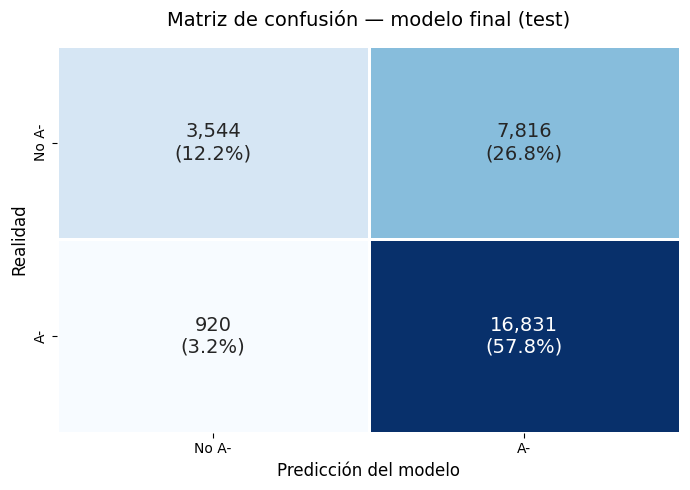


Recall A- (sensibilidad para riesgo): 94.8%
Precision A- (de los flagueados, cuántos eran riesgo): 68.3%
Especificidad (cuántos no-riesgo bien clasificados): 31.2%


In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y2_test, y_test_pred_v2)

# Anotaciones con conteo absoluto y porcentaje sobre el total
total = cm.sum()
labels = np.array([[f"{cm[i,j]:,}\n({cm[i,j]/total:.1%})"
                    for j in range(cm.shape[1])] for i in range(cm.shape[0])])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=labels, fmt="", cmap="Blues",
            xticklabels=["No A-", "A-"],
            yticklabels=["No A-", "A-"],
            cbar=False, linewidths=1, linecolor="white",
            annot_kws={"size": 14})
plt.xlabel("Predicción del modelo", fontsize=12)
plt.ylabel("Realidad", fontsize=12)
plt.title("Matriz de confusión — modelo final (test)", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("matriz_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nRecall A- (sensibilidad para riesgo): {cm[1,1]/cm[1].sum():.1%}")
print(f"Precision A- (de los flagueados, cuántos eran riesgo): {cm[1,1]/cm[:,1].sum():.1%}")
print(f"Especificidad (cuántos no-riesgo bien clasificados): {cm[0,0]/cm[0].sum():.1%}")


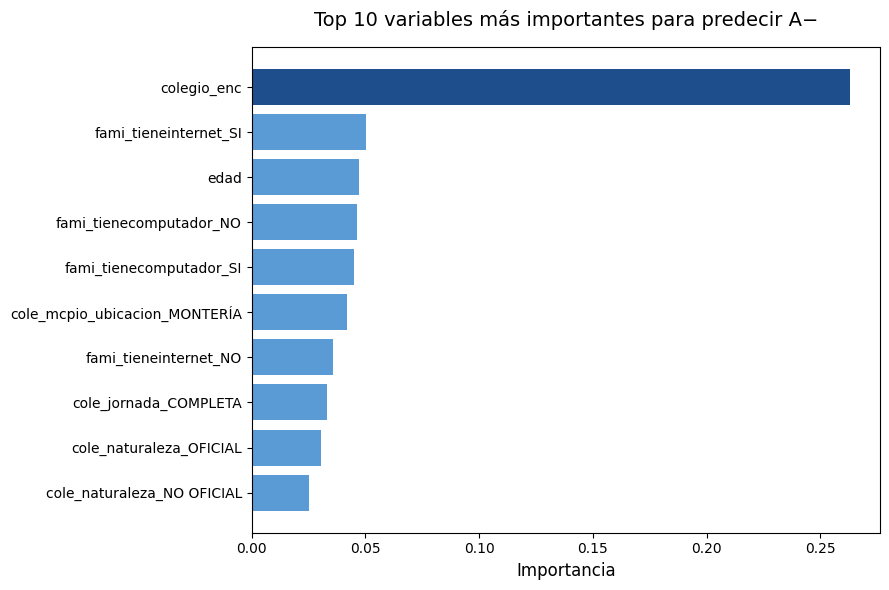

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
rf.fit(X2_train_p, y2_train)

feature_names = preprocessor_v2.get_feature_names_out()
importances = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(10)

# Limpiar nombres feos
importances["feature"] = (importances["feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
    .str.replace("ord__", "", regex=False))

plt.figure(figsize=(9, 6))
colors = ["#1f4e8c"] + ["#5b9bd5"] * 9
plt.barh(importances["feature"][::-1], importances["importance"][::-1], color=colors[::-1])
plt.xlabel("Importancia", fontsize=12)
plt.title("Top 10 variables más importantes para predecir A−", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("importancia_variables.png", dpi=150, bbox_inches="tight")
plt.show()


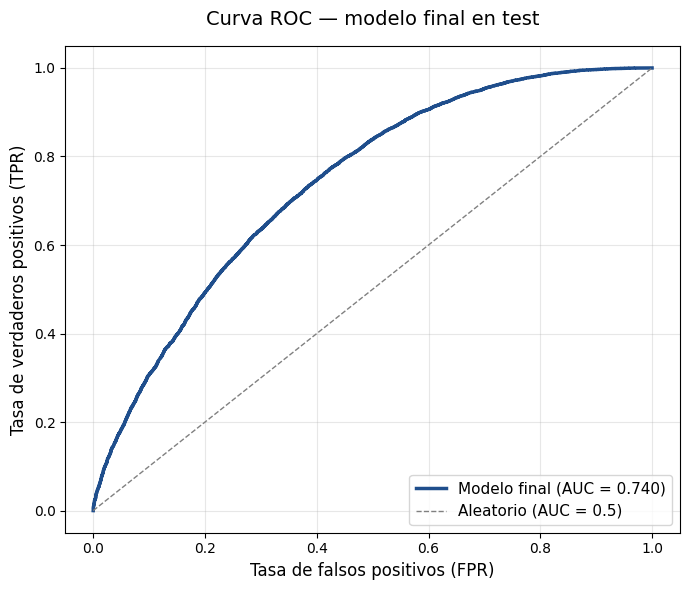

In [27]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y2_test, y_test_proba_v2)
auc = roc_auc_score(y2_test, y_test_proba_v2)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#1f4e8c", linewidth=2.5, label=f"Modelo final (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Aleatorio (AUC = 0.5)")
plt.xlabel("Tasa de falsos positivos (FPR)", fontsize=12)
plt.ylabel("Tasa de verdaderos positivos (TPR)", fontsize=12)
plt.title("Curva ROC — modelo final en test", fontsize=14, pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("curva_roc.png", dpi=150, bbox_inches="tight")
plt.show()
